In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#设置图标样式
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(12,8) 
plt.rcParams["figure.dpi"]=100

#pandas显示选项
pd.set_option("display.max_columns", None) #显示所有列
pd.set_option("display.max_rows", 100) #最多显示100行数据
pd.set_option("display.float_format", '{:.2f}'.format) #设置浮点数显示两位小数

print("环境已设置完成！")

环境已设置完成！


In [128]:
#加载数据
file_path = "电商行为数据.xlsx"
df=pd.read_excel(file_path,sheet_name="客户行为数据")
print("加载成功")
print(f"数据形状：{df.shape}")
print("\n数据列名：")
for i,col in enumerate(df.columns,1):
    print(f"{i:2d}. {col}")


加载成功
数据形状：(5630, 19)

数据列名：
 1. 顾客ID
 2. 流失标志
 3. 使用平台时长（月）
 4. 首选登录设备
 5. 城市等级
 6. 仓库到顾客家的距离（公里）
 7. 婚姻状况
 8. 年龄分组
 9. 性别
10. APP使用时长（小时）
11. 上月订单数量
12. 订单金额较去年增长百分比
13. 距上次下单天数
14. 上月首选订单类别
15. 关注的主播数量
16. 服务满意度评分
17. 上月投诉情况
18. 上月使用优惠券数量
19. 上月平均返现金额


In [129]:
print("数据基本信息：")

#数据预览(前五行)
print("\n数据预览(前五行)：")
display(df.head())

#数据预览(后五行)
print("\n数据预览(后五行)：")
display(df.tail())


数据基本信息：

数据预览(前五行)：


,顾客ID,流失标志,使用平台时长（月）,首选登录设备,城市等级,仓库到顾客家的距离（公里）,婚姻状况,年龄分组,性别,APP使用时长（小时）,上月订单数量,订单金额较去年增长百分比,距上次下单天数,上月首选订单类别,关注的主播数量,服务满意度评分,上月投诉情况,上月使用优惠券数量,上月平均返现金额
0,50001,流失,4.00,手机,三线城市,6.00,单身,30-39岁,女性,3.00,1.00,11.00,5.00,笔记本电脑及配件类,9,2,有,1.00,159.93
1,50002,流失,NaN,手机（可能为功能机）,一线城市,8.00,单身,40-49岁,男性,3.00,1.00,15.00,0.00,家居类,7,3,有,0.00,120.90
2,50003,流失,NaN,手机（可能为功能机）,一线城市,30.00,单身,40-49岁,男性,2.00,1.00,14.00,3.00,家居类,6,3,有,0.00,120.28
3,50004,流失,3.00,手机（可能为功能机）,三线城市,15.00,单身,40-49岁,男性,2.00,1.00,23.00,3.00,笔记本电脑及配件类,8,5,无,0.00,134.07
4,50005,流失,3.00,手机（可能为功能机）,一线城市,12.00,单身,30-39岁,男性,NaN,1.00,11.00,3.00,家居类,3,5,无,1.00,129.60



数据预览(后五行)：


,顾客ID,流失标志,使用平台时长（月）,首选登录设备,城市等级,仓库到顾客家的距离（公里）,婚姻状况,年龄分组,性别,APP使用时长（小时）,上月订单数量,订单金额较去年增长百分比,距上次下单天数,上月首选订单类别,关注的主播数量,服务满意度评分,上月投诉情况,上月使用优惠券数量,上月平均返现金额
5625,55626,未流失,13.00,平板电脑,一线城市,30.00,已婚,20-29岁,男性,3.00,2.00,18.00,4.00,笔记本电脑及配件类,6,1,无,1.00,150.71
5626,55627,未流失,13.00,手机,一线城市,13.00,已婚,50-59岁,男性,3.00,2.00,16.00,NaN,时尚类,6,5,无,1.00,224.91
5627,55628,未流失,1.00,手机,一线城市,11.00,已婚,20-29岁,男性,3.00,2.00,21.00,4.00,笔记本电脑及配件类,3,4,有,1.00,186.42
5628,55629,未流失,23.00,平板电脑,三线城市,9.00,已婚,50-59岁,男性,4.00,2.00,15.00,9.00,笔记本电脑及配件类,4,4,无,2.00,178.90
5629,55630,未流失,8.00,手机,一线城市,15.00,已婚,20-29岁,男性,3.00,2.00,13.00,3.00,笔记本电脑及配件类,4,3,无,2.00,169.04


In [130]:
#数值类型描述性统计
print("\n数值类型描述性统计：")
numberic_cols=df.select_dtypes(include=[np.number]).columns.to_list()
if numberic_cols:
    display(df[numberic_cols].describe().T)


数值类型描述性统计：


,count,mean,std,min,25%,50%,75%,max
顾客ID,5630.00,52815.50,1625.39,50001.00,51408.25,52815.50,54222.75,55630.00
使用平台时长（月）,5366.00,10.69,8.45,1.00,3.00,9.00,16.00,63.00
仓库到顾客家的距离（公里）,5379.00,15.64,8.53,5.00,9.00,14.00,20.00,127.00
APP使用时长（小时）,5375.00,2.93,0.72,0.00,2.00,3.00,3.00,5.00
上月订单数量,5372.00,3.01,2.94,1.00,1.00,2.00,3.00,16.00
订单金额较去年增长百分比,5365.00,15.71,3.68,11.00,13.00,15.00,18.00,26.00
距上次下单天数,5323.00,4.54,3.65,0.00,2.00,3.00,7.00,46.00
关注的主播数量,5630.00,4.21,2.58,1.00,2.00,3.00,6.00,22.00
服务满意度评分,5630.00,3.07,1.38,1.00,2.00,3.00,4.00,5.00
上月使用优惠券数量,5374.00,1.75,1.89,0.00,1.00,1.00,2.00,16.00


In [131]:
print("分类型变量列描述统计")

object_cols=df.select_dtypes(include=["object"]).columns.to_list()

for col in object_cols:
    print(f"\n{col}取值分布：")
    value_counts=df[col].value_counts(dropna=False)#计算每个参数出现的次数，包括空值
    value_counts_pct=df[col].value_counts(normalize=True, dropna=False)*100 #计算每个参数出现的百分比，包括空值
    value_df=pd.DataFrame({
        "数量: ": value_counts,
        "百分比: ": value_counts_pct.round(2)
    })
    display(value_df.head(10))

分类型变量列描述统计

流失标志取值分布：


,数量:,百分比:
流失标志,,
未流失,4682,83.16
流失,948,16.84



首选登录设备取值分布：


,数量:,百分比:
首选登录设备,,
手机,2765,49.11
平板电脑,1634,29.02
手机（可能为功能机）,1231,21.87



城市等级取值分布：


...

,数量:,百分比:
性别,,
男性,3384,60.11
女性,2246,39.89



上月首选订单类别取值分布：


,数量:,百分比:
上月首选订单类别,,
笔记本电脑及配件类,2050,36.41
手机类,1271,22.58
时尚类,826,14.67
家居类,809,14.37
食品杂货类,410,7.28
其他类,264,4.69



上月投诉情况取值分布：


,数量:,百分比:
上月投诉情况,,
无,4026,71.51
有,1604,28.49


In [132]:
#重复性检查
duplicates=df.duplicated().sum()
print(f"\n数据中重复行数：{duplicates}")

if duplicates > 0:
    print(f"重复比例：{(duplicates/len(df)*100):.2f}%")
else:
    print("数据中没有重复行")

#唯一值检查
print("\n各列唯一值检查：")
unique_count={}
for col in df.columns:
    unique_count[col]=df[col].nunique()

unique_df=pd.DataFrame(list(unique_count.items()), columns=["列名", "唯一值数量"])
unique_df=unique_df.sort_values("唯一值数量", ascending=False) #按照唯一值数量降序排列
display(unique_df)


数据中重复行数：0
数据中没有重复行

各列唯一值检查：


,列名,唯一值数量
0,顾客ID,5630
18,上月平均返现金额,2586
5,仓库到顾客家的距离（公里）,34
2,使用平台时长（月）,33
12,距上次下单天数,22
17,上月使用优惠券数量,17
11,订单金额较去年增长百分比,16
10,上月订单数量,16
14,关注的主播数量,15
7,年龄分组,6


第二部分：数据清洗

In [133]:
#创建原始数据备份
df_original=df.copy()
print(f"备份数据形状：{df_original.shape}")

备份数据形状：(5630, 19)


In [134]:
#处理缺失值

#检查缺失情况
missing_summary={}
for col in df.columns:
    missing_count=df[col].isnull().sum()
    if missing_count>0:
        missing_summary[col]={
            "缺失数量": missing_count,
            "缺失比例(%)":(missing_count/len(df)*100).round(2),
            "数据类型":df[col].dtype
        }

#处理缺失值
if missing_summary:
    missing_df=pd.DataFrame(missing_summary).T
    print("缺失值统计:")
    display(missing_df)

    #根据缺失比例和数据类型进行处理
    for col, info in missing_summary.items():
        dtype=info["数据类型"]
        missing_pct=info["缺失比例(%)"]

        #缺失比例小于5%，删除缺失行
        if missing_pct < 5:
            print(f"'{col}':缺失比例{missing_pct}%,小于5%，删除缺失行")
            df=df.dropna(subset=[col]) #删除该列缺失值所在行

        #数据值：用中位数进行填充
        elif dtype in ["int64", "float64"]:
            median_val=df[col].median() #计算中位数
            print(f"'{col}':数据型变量，使用中位数{median_val:.2f}进行填充")
            df[col]=df[col].fillna(median_val) #用中位数填充缺失值

        #分类型：用众数进行填充
        elif dtype == "object":
            mode_val=df[col].mode()[0]  if not df[col].mode().empty else "未知" #计算众数
            print(f"'{col}':分类型变量，使用众数{mode_val}进行填充")
            df[col]=df[col].fillna(mode_val) #用众数填充缺失值  

else:
    print("数据中没有缺失值!")

print(f"\n处理缺失值后数据形状为: {df.shape}")

缺失值统计:


,缺失数量,缺失比例(%),数据类型
使用平台时长（月）,264,4.69,float64
仓库到顾客家的距离（公里）,251,4.46,float64
APP使用时长（小时）,255,4.53,float64
上月订单数量,258,4.58,float64
订单金额较去年增长百分比,265,4.71,float64
距上次下单天数,307,5.45,float64
上月使用优惠券数量,256,4.55,float64


'使用平台时长（月）':缺失比例4.69%,小于5%，删除缺失行
'仓库到顾客家的距离（公里）':缺失比例4.46%,小于5%，删除缺失行
'APP使用时长（小时）':缺失比例4.53%,小于5%，删除缺失行
'上月订单数量':缺失比例4.58%,小于5%，删除缺失行
'订单金额较去年增长百分比':缺失比例4.71%,小于5%，删除缺失行
'距上次下单天数':数据型变量，使用中位数3.00进行填充
'上月使用优惠券数量':缺失比例4.55%,小于5%，删除缺失行

处理缺失值后数据形状为: (4081, 19)


异常值检测结果: 


,异常值数量,异常值比例(%),最小值,第一四分位数,中位数,第三四分位数,最大值,下限,上限
使用平台时长（月）,74.00,1.81,1.00,3.00,8.00,14.00,53.00,-13.50,30.50
仓库到顾客家的距离（公里）,2.00,0.05,5.00,9.00,14.00,21.00,127.00,-9.00,39.00
APP使用时长（小时）,2012.00,49.30,0.00,3.00,3.00,3.00,5.00,3.00,3.00
上月订单数量,502.00,12.30,1.00,1.00,2.00,3.00,16.00,-2.00,6.00
订单金额较去年增长百分比,25.00,0.61,11.00,13.00,15.00,18.00,26.00,5.50,25.50
距上次下单天数,23.00,0.56,0.00,2.00,3.00,7.00,46.00,-5.50,14.50
关注的主播数量,3.00,0.07,1.00,2.00,3.00,6.00,22.00,-4.00,12.00
上月使用优惠券数量,472.00,11.57,0.00,1.00,1.00,2.00,16.00,-0.50,3.50
上月平均返现金额,36.00,0.88,0.00,149.04,163.16,183.55,324.99,97.27,235.32


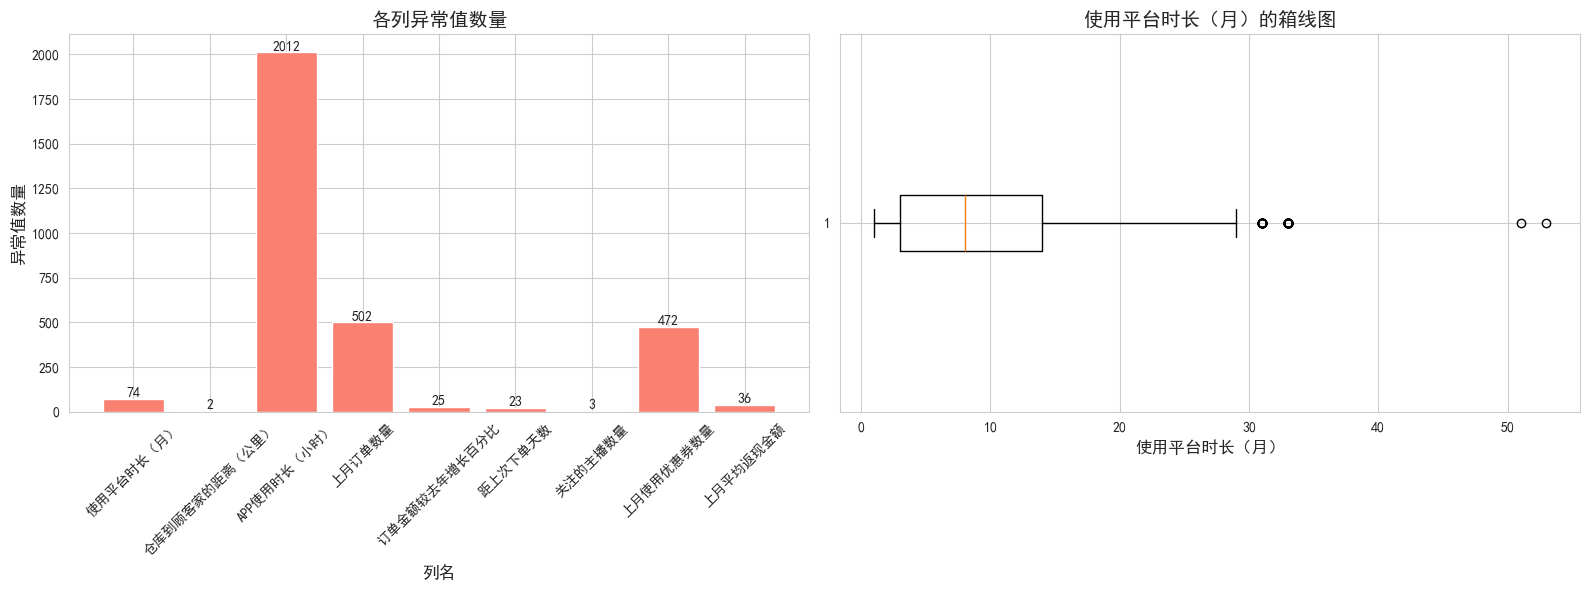


使用缩尾法进行处理
使用平台时长（月）:将值限制在[1.00,33.00]范围内
仓库到顾客家的距离（公里）:将值限制在[6.00,36.00]范围内
APP使用时长（小时）:将值限制在[2.00,4.00]范围内
上月订单数量:将值限制在[1.00,13.00]范围内
订单金额较去年增长百分比:将值限制在[11.00,25.00]范围内
距上次下单天数:将值限制在[0.00,13.00]范围内
关注的主播数量:将值限制在[1.00,11.00]范围内
上月使用优惠券数量:将值限制在[0.00,8.00]范围内
上月平均返现金额:将值限制在[131.80,230.52]范围内
数值型列当中没有检测到异常值


In [135]:
#处理异常值

#设置中文字体
plt.rcParams["font.sans-serif"]=["SimHei"] #设置中文字体为SimHei
plt.rcParams["axes.unicode_minus"]=False #解决负号显示问题

#筛选数值类型列
numeric_cols=df.select_dtypes(include=[np.number]).columns.to_list()

if numberic_cols:
    outlier_info={}

    for col in numeric_cols:
        Q1=df[col].quantile(0.25) #第一四分位数
        Q3=df[col].quantile(0.75) #第三四分位数
        IQR=Q3-Q1

        #获取上下限
        lower_bound=Q1-1.5*IQR
        upper_bound=Q3+1.5*IQR

        #检查异常值(超出上下限的值)
        outliers=df[(df[col]<lower_bound) | (df[col]>upper_bound)]
        outlier_count=len(outliers)

        if outlier_count > 0:
                outlier_info[col]={
                    "异常值数量": outlier_count,
                    "异常值比例(%)": round(outlier_count/len(df)*100, 2),
                    "最小值": df[col].min(),
                    "第一四分位数": Q1,
                    "中位数": df[col].median(),
                    "第三四分位数": Q3,
                    "最大值": df[col].max(),
                    "下限": lower_bound,
                    "上限": upper_bound
                }

    if outlier_info:
        outlier_df=pd.DataFrame(outlier_info).T
        print("异常值检测结果: ")
        display(outlier_df)

        #可视化处理
        fig,axes=plt.subplots(1,2,figsize=(16,6))

        #左侧：异常值哦数量条形图
        outlier_count=[info["异常值数量"]for info in outlier_info.values()]
        cols_with_outliers=list(outlier_info.keys())

        axes[0].bar(cols_with_outliers,outlier_count,color="salmon")
        axes[0].set_title("各列异常值数量",fontsize=14,fontweight="bold")
        axes[0].set_xlabel("列名",fontsize=12)
        axes[0].set_ylabel("异常值数量",fontsize=12)
        axes[0].tick_params(axis="x",rotation=45)


        #在条形图上添加具体数值标签
        for i,v in enumerate(outlier_count):
            axes[0].text(i,v+0.5,str(v),ha="center",va="bottom",fontsize=10)

        #右侧使用箱体图（选择一个有异常值的列）
        example_col= cols_with_outliers[0] if cols_with_outliers else numeric_cols[0]
        axes[1].boxplot(df[example_col].dropna(), vert=False)
        axes[1].set_title(f"{example_col}的箱线图", fontsize=14, fontweight="bold")
        axes[1].set_xlabel(example_col, fontsize=12)

        plt.tight_layout()
        plt.show()

        #使用缩尾法进行处理
        print("\n使用缩尾法进行处理")
        for col in cols_with_outliers:
            Q1=df[col].quantile(0.01)
            Q3=df[col].quantile(0.99)

            #将超出1%与99%的值替换为边界值，进行缩尾
            df[col]=np.clip(df[col], Q1, Q3)
            print(f"{col}:将值限制在[{Q1:.2f},{Q3:.2f}]范围内")
        else:
            print("数值型列当中没有检测到异常值")

    else:
        print("数据中没有数值型变量")



In [136]:
#创建衍生特征

#创建活跃用户特征，距上次下单天数小于30天，视为活跃用户
df["是否活跃用户"] =df["距上次下单天数"].apply(lambda x: "活跃" if x < 30 else "不活跃")

#创建消费水平特征-基于上月平均返现金额决定
def get_consumption_level(amount):
    if amount < 100:
        return "低消费"
    elif amount < 200:
        return "中消费"
    else:
        return "高消费"

df["消费水平"] = df["上月平均返现金额"].apply(get_consumption_level)

#创建使用频率特征-给予上月订单数量
def get_frequency_level(count):
    if count == 0:
        return "无订单"
    elif count <= 2:
        return "低频"
    elif count <= 5:
        return "中频"
    else:
        return "高频"
    
df["使用频率"]=df["上月订单数量"].apply(get_frequency_level)
    
def get_satisfaction_group(score):
    if score <= 2:
        return "不满意"
    elif score <= 4:
        return "一般"
    else:
        return "满意"
    
df["满意度分组"]=df["服务满意度评分"].apply(get_satisfaction_group)

print(f"数据形状{df.shape}")
display(df.head())

数据形状(4081, 23)


,顾客ID,流失标志,使用平台时长（月）,首选登录设备,城市等级,仓库到顾客家的距离（公里）,婚姻状况,年龄分组,性别,APP使用时长（小时）,上月订单数量,订单金额较去年增长百分比,距上次下单天数,上月首选订单类别,关注的主播数量,服务满意度评分,上月投诉情况,上月使用优惠券数量,上月平均返现金额,是否活跃用户,消费水平,使用频率,满意度分组
0,50001,流失,4.00,手机,三线城市,6.00,单身,30-39岁,女性,3.00,1.00,11.00,5.00,笔记本电脑及配件类,9,2,有,1.00,159.93,活跃,中消费,低频,不满意
3,50004,流失,3.00,手机（可能为功能机）,三线城市,15.00,单身,40-49岁,男性,2.00,1.00,23.00,3.00,笔记本电脑及配件类,8,5,无,0.00,134.07,活跃,中消费,低频,满意
5,50006,流失,3.00,平板电脑,一线城市,22.00,单身,50-59岁,女性,3.00,6.00,22.00,7.00,手机类,2,5,有,4.00,139.19,活跃,中消费,高频,满意
11,50012,流失,11.00,手机,一线城市,6.00,单身,40-49岁,男性,3.00,1.00,13.00,0.00,时尚类,10,3,有,0.00,153.81,活跃,中消费,低频,一般
12,50013,流失,3.00,手机（可能为功能机）,一线城市,11.00,单身,30-39岁,男性,2.00,2.00,13.00,2.00,家居类,2,3,有,2.00,134.41,活跃,中消费,低频,一般


用户基本特征


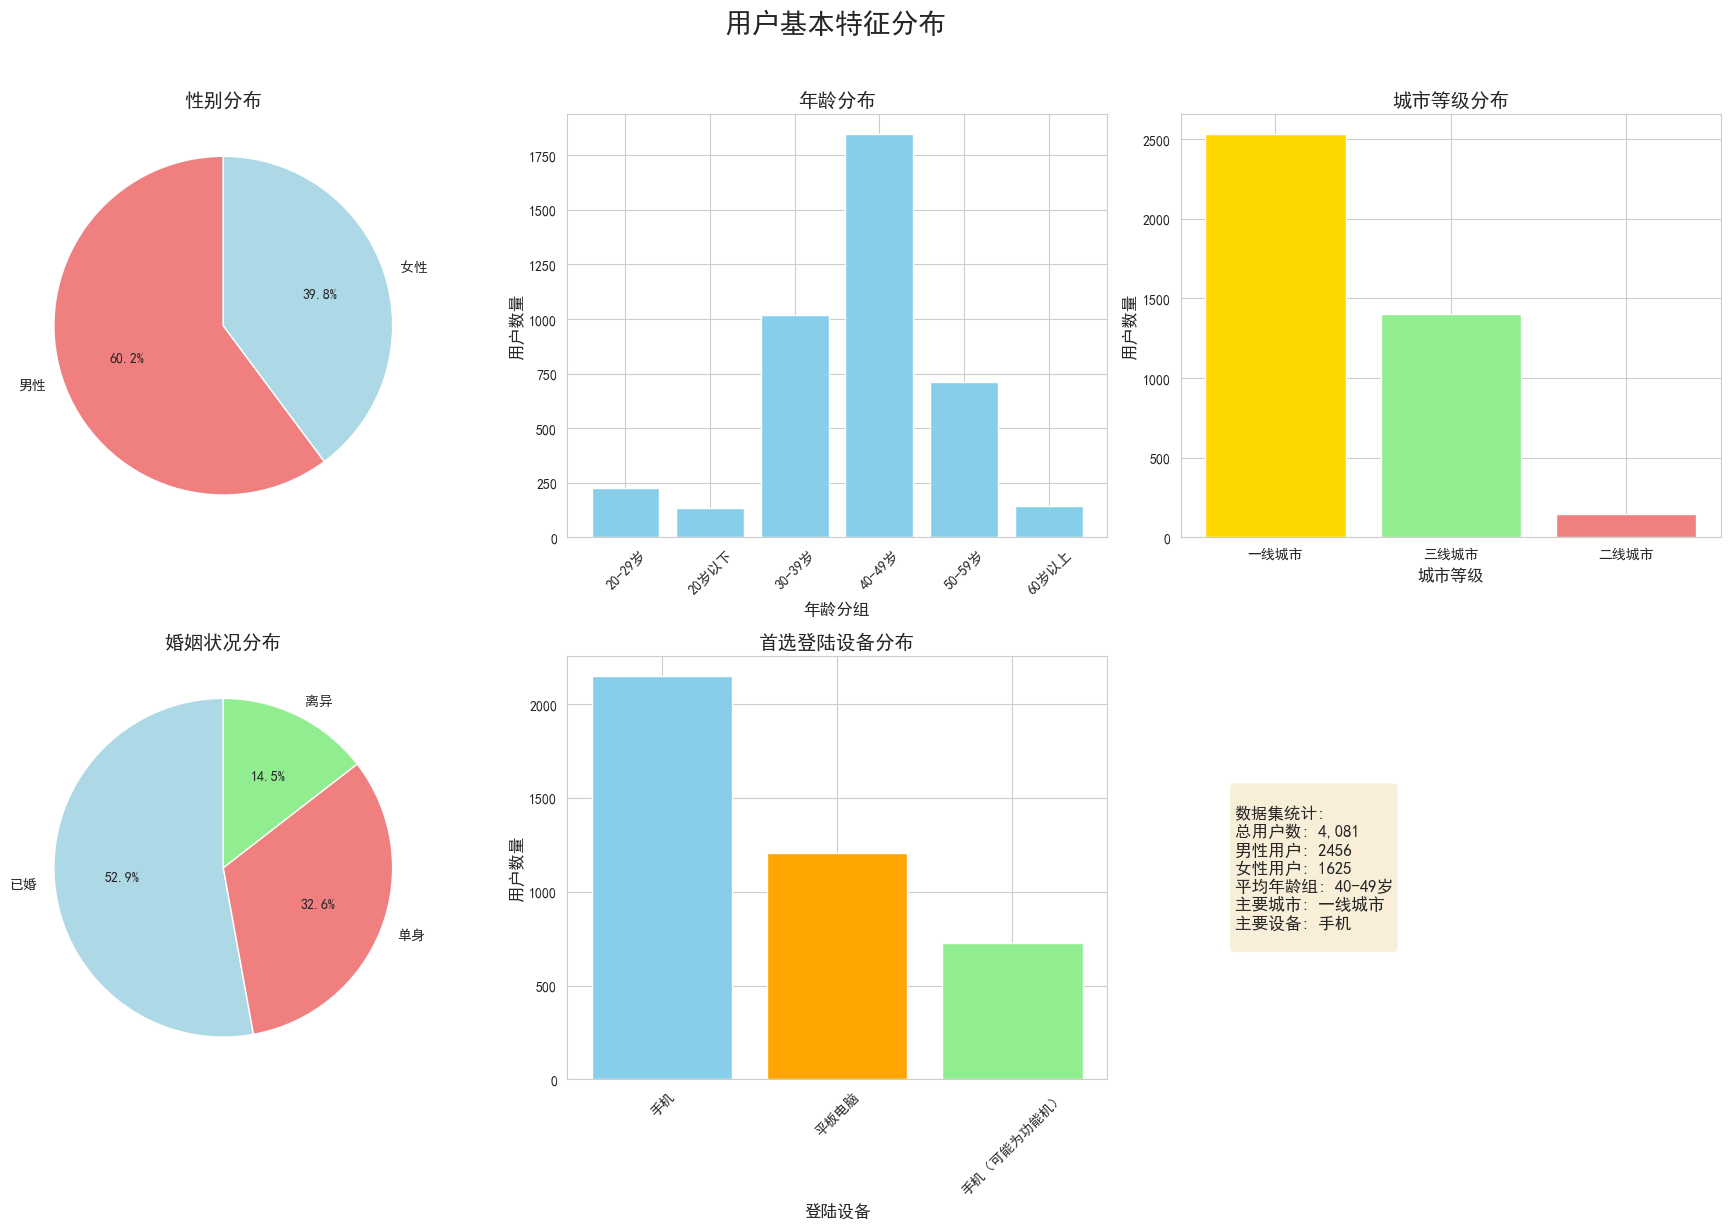

In [137]:
print("用户基本特征")

fig,axes=plt.subplots(2,3,figsize=(18,12))
fig.suptitle('用户基本特征分布',fontsize=20,fontweight='bold',y=1.02)

#性别分布子图
gender_counts=df["性别"].value_counts()
colors=["lightcoral","lightblue"]
wedges,texts,autotexts=axes[0,0].pie(gender_counts,labels=gender_counts.index,
                                     autopct='%1.1f%%',colors=colors,startangle=90)
axes[0,0].set_title("性别分布",fontsize=14,fontweight='bold')

#年龄分布子图-条形图
age_counts=df['年龄分组'].value_counts().sort_index()
axes[0,1].bar(age_counts.index,age_counts.values,color='skyblue')
axes[0,1].set_title('年龄分布',fontsize=14)
axes[0,1].set_xlabel('年龄分组',fontsize=12)
axes[0,1].set_ylabel('用户数量',fontsize=12)
#防止标签重叠，旋转x轴标签
axes[0,1].tick_params(axis='x', rotation=45)

# 城市等级分布-条形图
city_counts = df['城市等级'].value_counts()
axes[0,2].bar(city_counts.index, city_counts.values, color=['gold', 'lightgreen', 'lightcoral'])
axes[0,2].set_title('城市等级分布', fontsize=14, fontweight="bold")
axes[0,2].set_xlabel('城市等级', fontsize=12)
axes[0,2].set_ylabel('用户数量', fontsize=12)

# 婚姻状况-扇形图
marital_counts = df['婚姻状况'].value_counts()
marital_color = ['lightblue', 'lightcoral', 'lightgreen']
wedges, texts, autotexts = axes[1,0].pie(marital_counts.values, labels=marital_counts.index,
                                         autopct='%1.1f%%', colors=marital_color, startangle=90)
axes[1,0].set_title('婚姻状况分布', fontsize=14, fontweight='bold')

# 首选登陆设备
device_counts = df['首选登录设备'].value_counts()
axes[1,1].bar(device_counts.index, device_counts.values, color=['skyblue', 'orange', 'lightgreen'])
axes[1,1].set_title('首选登陆设备分布', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('登陆设备', fontsize=12)
axes[1,1].set_ylabel('用户数量', fontsize=12)
#旋转X轴标签45度
axes[1,1].tick_params(axis='x',rotation=45)

# 隐藏最后一个子图
axes[1,2].axis('off')
stats_text = f"""
数据集统计:
总用户数: {len(df):,}
男性用户: {gender_counts.get("男性", 0)}
女性用户: {gender_counts.get("女性", 0)}
平均年龄组: {df['年龄分组'].mode()[0]}
主要城市: {city_counts.index[0]}
主要设备: {device_counts.index[0]}
"""

axes[1,2].text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


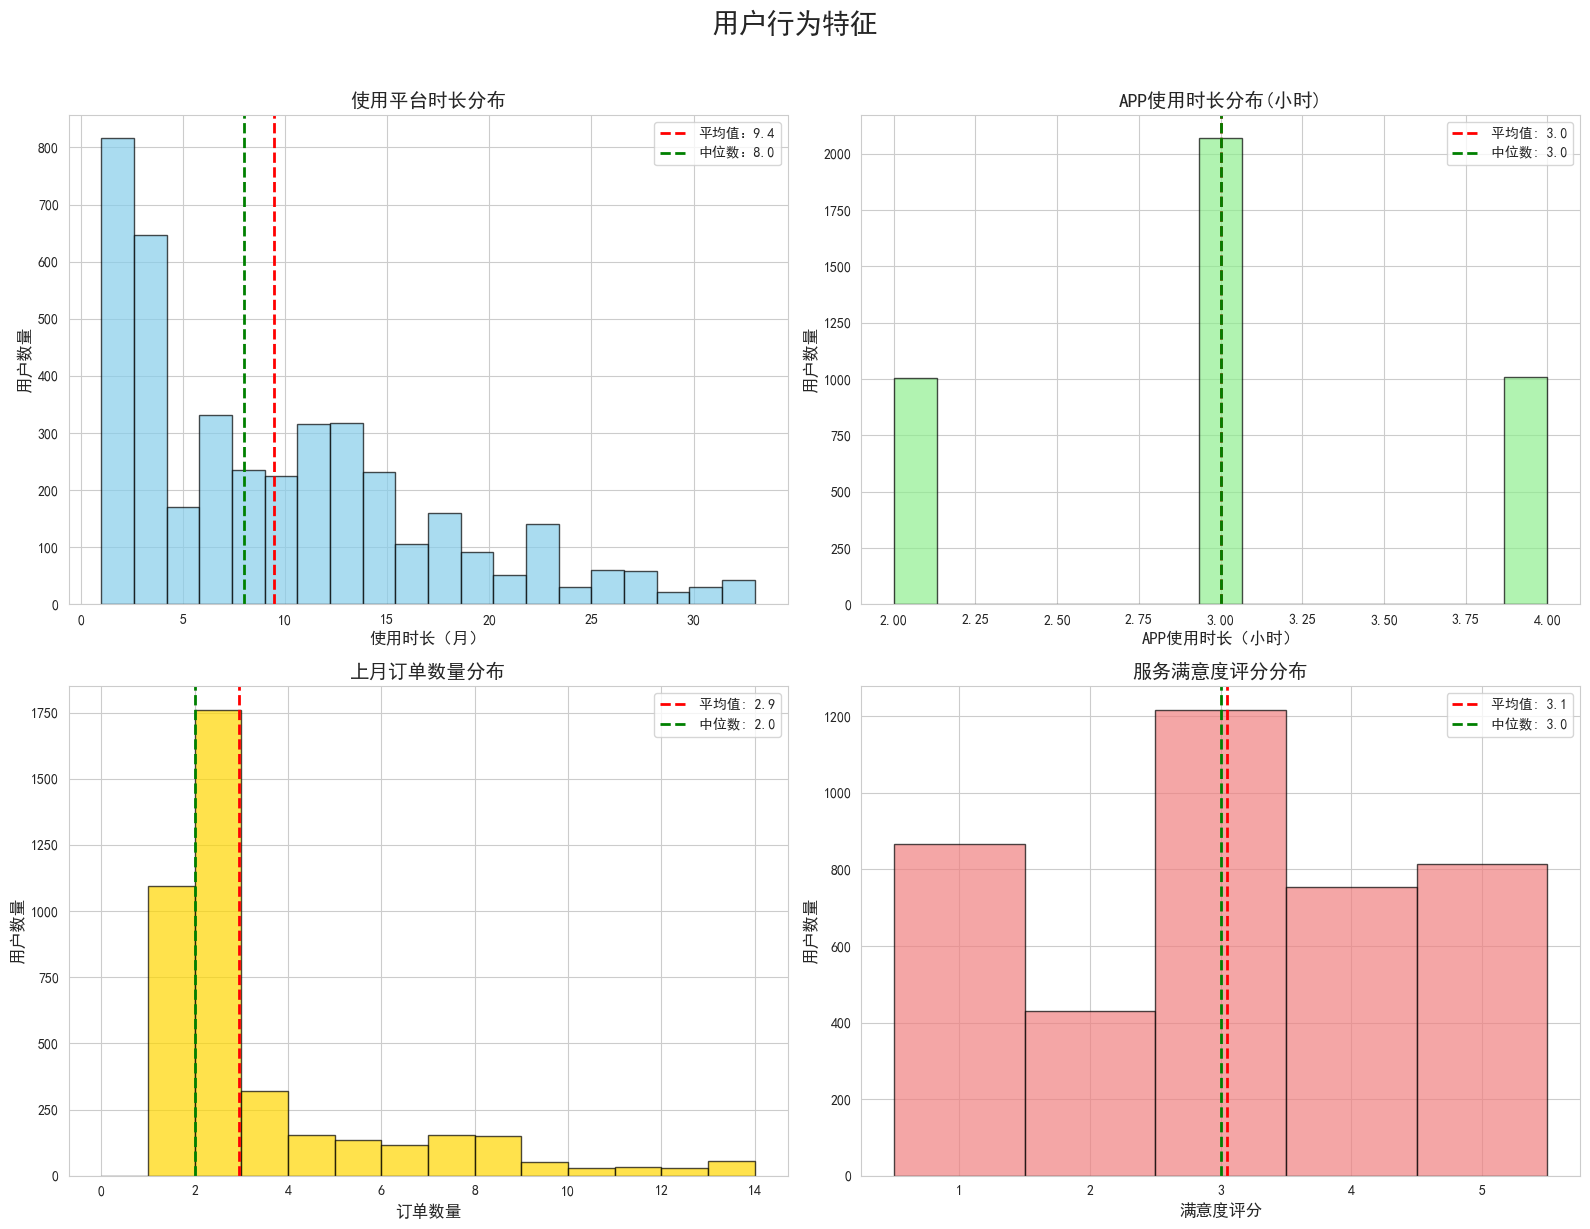

In [139]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('用户行为特征', fontsize=20, fontweight='bold', y=1.02)

if '使用平台时长（月）' in df.columns:
    tenure_data = df['使用平台时长（月）'].dropna()
    axes[0,0].hist(tenure_data, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0,0].axvline(tenure_data.mean(), color='red', linestyle='--', linewidth=2, label=f'平均值：{tenure_data.mean():.1f}')
    axes[0,0].axvline(tenure_data.median(), color='green', linestyle='--', linewidth=2, label=f'中位数：{tenure_data.median():.1f}')
    axes[0,0].set_title('使用平台时长分布', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('使用时长（月）', fontsize=12)
    axes[0,0].set_ylabel('用户数量', fontsize=12)
    axes[0,0].legend()

# APP使用时长
if 'APP使用时长（小时）' in df.columns:
    app_data = df['APP使用时长（小时）'].dropna()
    # 绘制直方图：15个区间，浅绿色
    axes[0, 1].hist(app_data, bins=15, color='lightgreen', edgecolor='black', alpha=0.7)
    # 添加平均值线和中位数线
    axes[0, 1].axvline(app_data.mean(), color='red', linestyle='--', linewidth=2,
                       label=f'平均值: {app_data.mean():.1f}')
    axes[0, 1].axvline(app_data.median(), color='green', linestyle='--', linewidth=2,
                       label=f'中位数: {app_data.median():.1f}')
    axes[0, 1].set_title('APP使用时长分布(小时)', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('APP使用时长（小时）', fontsize=12)
    axes[0, 1].set_ylabel('用户数量', fontsize=12)
    axes[0, 1].legend()

if '上月订单数量' in df.columns:
    order_data = df['上月订单数量']
    axes[1,0].hist(order_data, bins=np.arange(0, order_data.max() + 2), color='gold', edgecolor='black', alpha=0.7)
    axes[1,0].axvline(order_data.mean(), color='red', linestyle='--', linewidth=2, label=f'平均值: {order_data.mean():.1f}')
    axes[1,0].axvline(order_data.median(), color='green', linestyle='--', linewidth=2, label=f'中位数: {order_data.median():.1f}')
    axes[1,0].set_title('上月订单数量分布', fontsize=14, fontweight='bold')
    axes[1,0].set_xlabel('订单数量', fontsize=12)
    axes[1,0].set_ylabel('用户数量', fontsize=12)
    axes[1,0].legend()

if '服务满意度评分' in df.columns:
    satisfaction_data = df['服务满意度评分']
    axes[1,1].hist(satisfaction_data, bins=np.arange(1, 7), align='left', color='lightcoral', edgecolor='black', alpha=0.7)
    axes[1,1].axvline(satisfaction_data.mean(), color='red', linestyle='--', linewidth=2, label=f'平均值: {satisfaction_data.mean():.1f}')
    axes[1,1].axvline(satisfaction_data.median(), color='green', linestyle='--', linewidth=2, label=f'中位数: {satisfaction_data.median():.1f}')
    axes[1,1].set_title('服务满意度评分分布', fontsize=14, fontweight='bold')
    axes[1,1].set_xlabel('满意度评分', fontsize=12)
    axes[1,1].set_ylabel('用户数量', fontsize=12)
    axes[1,1].set_xticks(range(1, 6))
    axes[1,1].legend()

plt.tight_layout()
plt.show()